# Lab07 - Bài toán phân lớp dữ liệu bệnh tiểu đường Pima Indians

## 1. Import thư viện

In [32]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

plt.rcParams["figure.figsize"] = (8, 5)
%matplotlib inline

## 2. Thiết lập thư mục làm việc và nơi lưu kết quả

In [33]:

from pathlib import Path

# Xác định thư mục gốc của project tương đối so với notebook
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().resolve().parent
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "Lab07_Project").exists():
        PROJECT_ROOT = (PROJECT_ROOT / "Lab07_Project").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = RESULTS_DIR / "models"

for folder in [RESULTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("TABLES_DIR:", TABLES_DIR)
print("FIGURES_DIR:", FIGURES_DIR)


PROJECT_ROOT: C:\Users\HOME\Desktop\bao cao\Lab07\Lab07_Ver2
DATA_DIR: C:\Users\HOME\Desktop\bao cao\Lab07\Lab07_Ver2\data\raw
TABLES_DIR: C:\Users\HOME\Desktop\bao cao\Lab07\Lab07_Ver2\results\tables
FIGURES_DIR: C:\Users\HOME\Desktop\bao cao\Lab07\Lab07_Ver2\results\figures


## 3. Đọc dữ liệu

In [34]:
def load_pima_dataset():
    local_candidates = [
        "pima_diabetes.csv",
        "pima-indians-diabetes.csv",
        "diabetes.csv",
        str(DATA_DIR / "pima_diabetes.csv"),
        str(Path("data/raw/pima_diabetes.csv")),
        str(Path("../data/raw/pima_diabetes.csv"))
    ]

    for file_name in local_candidates:
        if os.path.exists(file_name):
            df_local = pd.read_csv(file_name)
            print(f"Đã đọc dữ liệu từ file cục bộ: {file_name}")
            return df_local

    print("Không tìm thấy file CSV cục bộ. Thử tải dữ liệu từ OpenML (data_id=37)...")
    diabetes = fetch_openml(data_id=37, as_frame=True, parser="auto")
    df_openml = diabetes.frame.copy()
    print("Đã tải dữ liệu từ OpenML.")
    return df_openml

df = load_pima_dataset()
df.head()


Đã đọc dữ liệu từ file cục bộ: C:\Users\HOME\Desktop\bao cao\Lab07\Lab07_Ver2\data\raw\pima_diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 4. Chuẩn hóa tên cột

In [35]:
expected_cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

rename_map = {
    "preg": "Pregnancies",
    "plas": "Glucose",
    "pres": "BloodPressure",
    "skin": "SkinThickness",
    "insu": "Insulin",
    "mass": "BMI",
    "pedi": "DiabetesPedigreeFunction",
    "age": "Age",
    "class": "Outcome",
    "tested_positive": "Outcome"
}

# đổi tên theo từ điển nếu cần
df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})

# xử lý trường hợp OpenML trả về cột mục tiêu là chuỗi
if "Outcome" in df.columns:
    if df["Outcome"].dtype == "object":
        df["Outcome"] = df["Outcome"].replace({"tested_negative": 0, "tested_positive": 1}).astype(int)

print("Tên cột hiện tại:")
print(list(df.columns))

Tên cột hiện tại:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


## 5. Kiểm tra kích thước dữ liệu

In [36]:
df.shape

(768, 9)

## 6. Kiểm tra thông tin chi tiết


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 8. Thống kê mô tả dữ liệu

`describe()` cho biết các giá trị:
- mean
- std
- min / max
- các tứ phân vị

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 9. Kiểm tra giá trị thiếu

Bước này kiểm tra missing values gốc trong dữ liệu.

In [39]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 10. Phân bố lớp mục tiêu

Biểu đồ này cho thấy số lượng bệnh nhân:
- không mắc tiểu đường
- mắc tiểu đường

Đây là bước quan trọng để xem dữ liệu có mất cân bằng lớp hay không.

Outcome
0    500
1    268
Name: count, dtype: int64

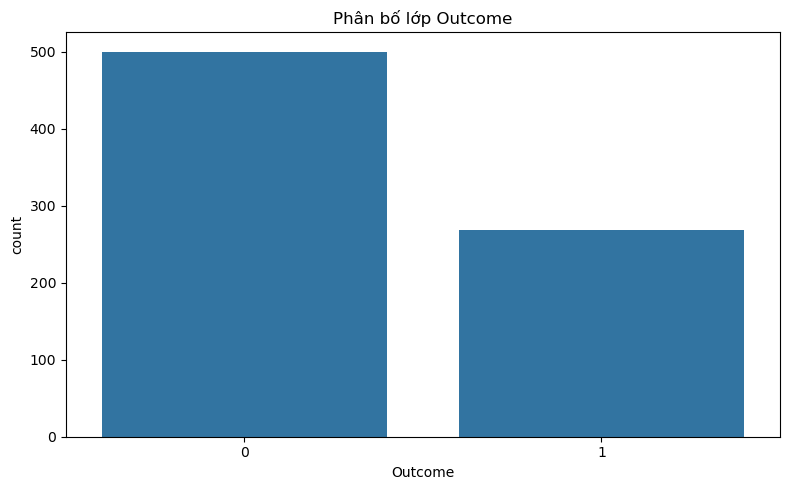

Tỷ lệ lớp:
Outcome
0    0.651
1    0.349
Name: count, dtype: float64


In [40]:
class_counts = df["Outcome"].value_counts().sort_index()
display(class_counts)

sns.countplot(x="Outcome", data=df)
plt.title("Phân bố lớp Outcome")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print("Tỷ lệ lớp:")
print((class_counts / len(df)).round(4))

## 11. Kiểm tra các giá trị 0 bất hợp lý

Trong bộ dữ liệu Pima Indians Diabetes, một số cột có giá trị bằng 0 nhưng về mặt y khoa là không hợp lý hoặc rất khó xảy ra:
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

Các giá trị này thường được xem như missing values ẩn.

In [41]:
zero_invalid_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = pd.Series({col: int((df[col] == 0).sum()) for col in zero_invalid_cols}, name="ZeroCount")
zero_counts.to_frame()

,ZeroCount
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


## 12. Histogram phân bố dữ liệu

Histogram giúp quan sát phân bố của từng thuộc tính và phát hiện sự lệch phân phối.

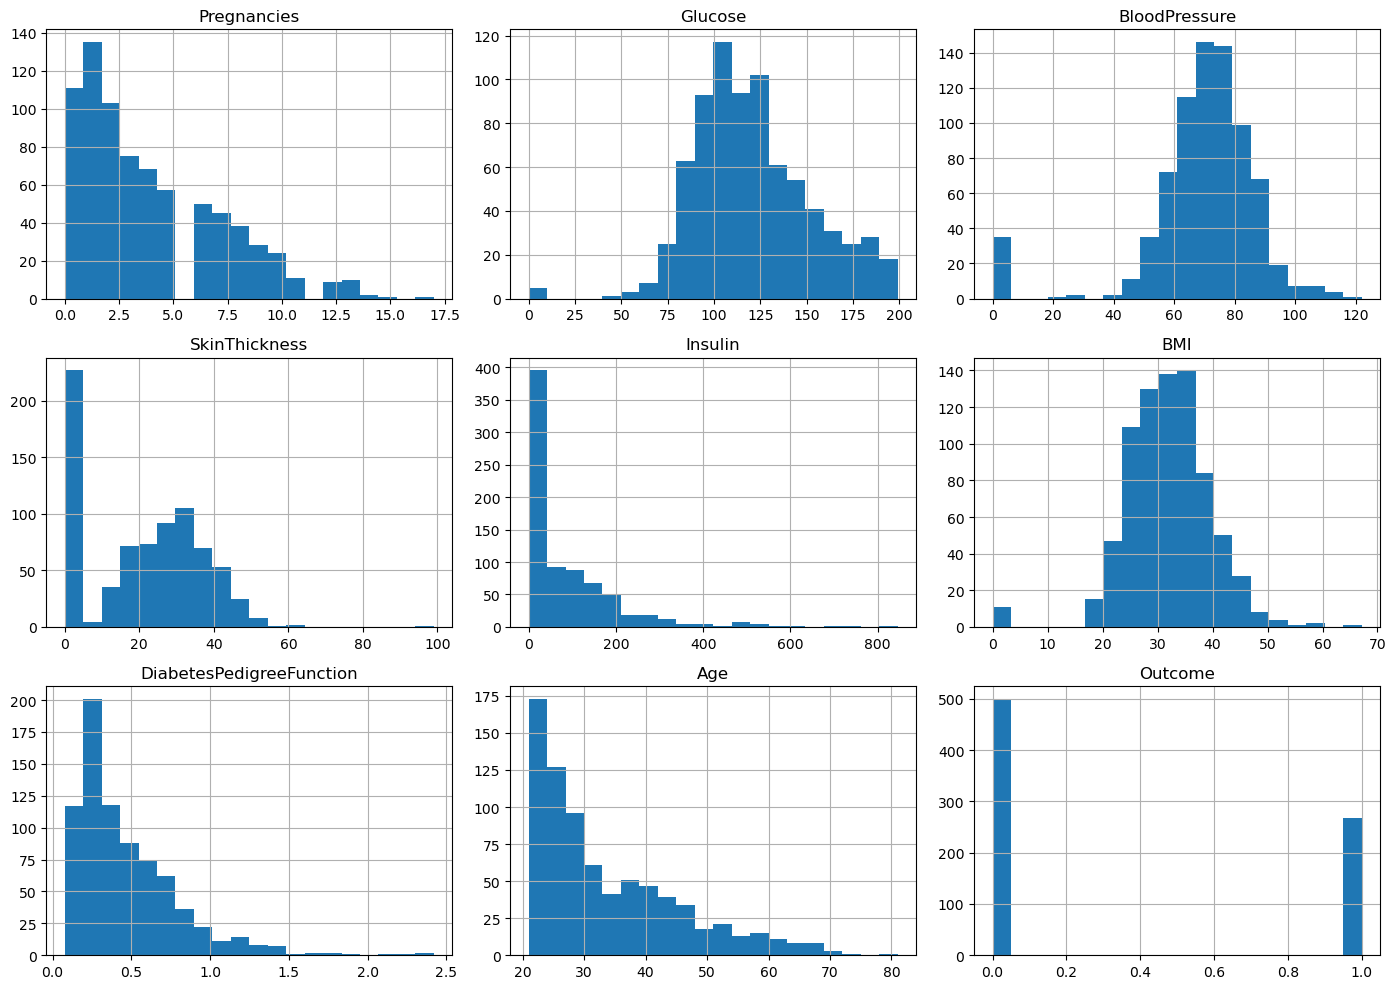

In [42]:
df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_histograms.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. Phát hiện ngoại lệ bằng boxplot

Boxplot giúp nhận biết nhanh các thuộc tính có nhiều giá trị bất thường hoặc phân bố lệch.

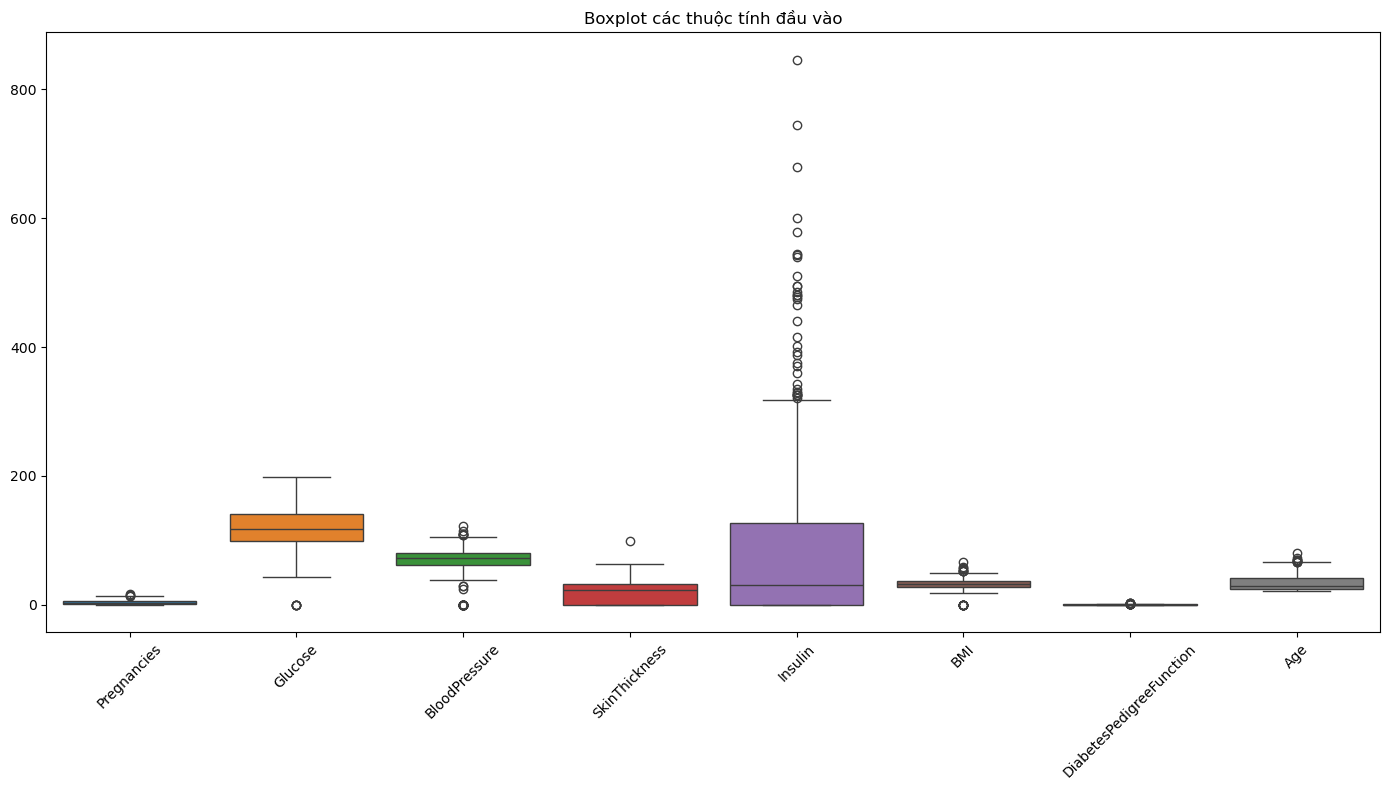

In [43]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df.drop(columns=["Outcome"]))
plt.xticks(rotation=45)
plt.title("Boxplot các thuộc tính đầu vào")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()

## 14. Phân tích tương quan giữa các biến

Heatmap giúp xem mức độ tương quan giữa các thuộc tính với nhau và với biến mục tiêu `Outcome`.

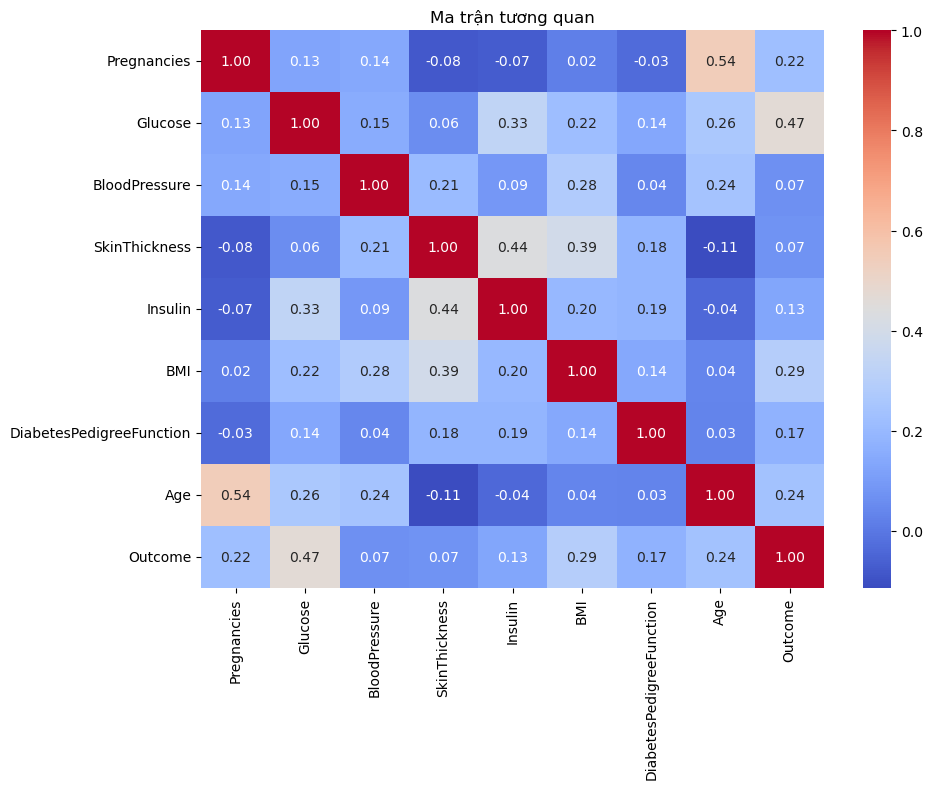

In [44]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 15. Làm sạch dữ liệu

Ta sẽ:
1. tách `X` và `y`
2. thay các giá trị 0 bất hợp lý bằng `NaN`
3. giữ nguyên việc điền khuyết ở trong pipeline để tránh rò rỉ dữ liệu

In [45]:
X = df.drop(columns=["Outcome"]).copy()
y = df["Outcome"].copy()

for col in zero_invalid_cols:
    X[col] = X[col].replace(0, np.nan)

print("Số lượng giá trị thiếu sau khi chuyển 0 -> NaN:")
display(X.isnull().sum())

Số lượng giá trị thiếu sau khi chuyển 0 -> NaN:


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

## 16. Chia dữ liệu train/test theo hold-out 7/3

Theo yêu cầu của bài lab:
- 70% dữ liệu dùng cho train
- 30% dữ liệu dùng cho test

Đồng thời dùng `stratify=y` để giữ tỷ lệ lớp ổn định giữa hai tập.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test :", X_test.shape)
print("Tỷ lệ lớp train:")
display(y_train.value_counts(normalize=True).sort_index().round(4))
print("Tỷ lệ lớp test:")
display(y_test.value_counts(normalize=True).sort_index().round(4))

Kích thước X_train: (537, 8)
Kích thước X_test : (231, 8)
Tỷ lệ lớp train:


Outcome
0    0.6518
1    0.3482
Name: proportion, dtype: float64

Tỷ lệ lớp test:


Outcome
0    0.6494
1    0.3506
Name: proportion, dtype: float64

## 17. Khởi tạo cross validation và các mô hình baseline

Các mô hình baseline gồm:
- Logistic Regression
- Linear Discriminant Analysis (LDA)
- K-Nearest Neighbors (KNN)
- Decision Tree
- Gaussian Naive Bayes
- Support Vector Machine (SVM)

Ta sẽ đánh giá các mô hình trên 3 dạng dữ liệu:
- raw
- minmax
- standard

In [47]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def get_models(preprocess_type="raw"):
    if preprocess_type == "raw":
        scaler = None
    elif preprocess_type == "minmax":
        scaler = MinMaxScaler()
    elif preprocess_type == "standard":
        scaler = StandardScaler()
    else:
        raise ValueError("preprocess_type must be 'raw', 'minmax' hoặc 'standard'")

    models = {
        "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
        "LDA": LinearDiscriminantAnalysis(),
        "KNN": KNeighborsClassifier(),
        "DecisionTree": DecisionTreeClassifier(random_state=42),
        "GaussianNB": GaussianNB(),
        "SVM": SVC(probability=True, random_state=42)
    }

    pipelines = {}
    for name, model in models.items():
        steps = [("imputer", SimpleImputer(strategy="median"))]

        # chuẩn hóa chủ yếu cần thiết cho các mô hình nhạy cảm với thang đo
        if scaler is not None and name in ["LogisticRegression", "LDA", "KNN", "GaussianNB", "SVM"]:
            steps.append(("scaler", scaler))

        steps.append(("model", model))
        pipelines[name] = Pipeline(steps)

    return pipelines

## 18. Hàm đánh giá trên tập test

Sau khi chọn được mô hình, ta đánh giá trên tập test bằng các độ đo:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [48]:
def evaluate_on_test(model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_score)
    }

## 19. Thực nghiệm baseline trên 3 kiểu tiền xử lý

Bước này:
1. huấn luyện từng mô hình bằng cross validation trên tập train
2. fit lại mô hình trên toàn bộ train
3. đánh giá trên tập test
4. lưu kết quả để so sánh

In [49]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

baseline_results = []

for prep in ["raw", "minmax", "standard"]:
    models = get_models(prep)

    for model_name, pipe in models.items():
        cv_result = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        pipe.fit(X_train, y_train)
        test_result = evaluate_on_test(pipe, X_test, y_test)

        baseline_results.append({
            "Preprocessing": prep,
            "Model": model_name,
            "CV_Accuracy_Mean": cv_result["test_accuracy"].mean(),
            "CV_Precision_Mean": cv_result["test_precision"].mean(),
            "CV_Recall_Mean": cv_result["test_recall"].mean(),
            "CV_F1_Mean": cv_result["test_f1"].mean(),
            "CV_AUC_Mean": cv_result["test_roc_auc"].mean(),
            "Test_Accuracy": test_result["Accuracy"],
            "Test_Precision": test_result["Precision"],
            "Test_Recall": test_result["Recall"],
            "Test_F1": test_result["F1-score"],
            "Test_AUC": test_result["AUC"]
        })

results_df = pd.DataFrame(baseline_results)
results_df

results_df.to_csv(TABLES_DIR / "baseline_results_all_models.csv", index=False)
print(f"Đã lưu bảng baseline vào: {TABLES_DIR / 'baseline_results_all_models.csv'}")


Đã lưu bảng baseline vào: C:\Users\HOME\Desktop\bao cao\Lab07\Lab07_Ver2\results\tables\baseline_results_all_models.csv


## 20. Bảng kết quả baseline theo từng kiểu dữ liệu

Ta sắp xếp theo `Test_Accuracy` để dễ quan sát mô hình tốt nhất trong từng nhóm tiền xử lý.

In [50]:
for prep in ["raw", "minmax", "standard"]:
    print("=" * 80)
    print(f"KẾT QUẢ BASELINE - {prep.upper()}")
    display(
        results_df[results_df["Preprocessing"] == prep]
        .sort_values(by=["Test_Accuracy", "Test_AUC"], ascending=False)
        .reset_index(drop=True)
    )

KẾT QUẢ BASELINE - RAW


,Preprocessing,Model,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_AUC_Mean,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC
0,raw,LogisticRegression,0.776730,0.737537,0.578655,0.635414,0.839390,0.744589,0.671875,0.530864,0.593103,0.834403
1,raw,SVM,0.757932,0.739776,0.492690,0.578196,0.814670,0.744589,0.720000,0.444444,0.549618,0.817037
2,raw,LDA,0.780433,0.753474,0.578655,0.640864,0.838020,0.735931,0.661290,0.506173,0.573427,0.834650
3,raw,GaussianNB,0.750664,0.668144,0.588889,0.619745,0.817953,0.727273,0.618421,0.580247,0.598726,0.803704
4,raw,KNN,0.730119,0.635792,0.567544,0.592227,0.774169,0.701299,0.583333,0.518519,0.549020,0.732140
5,raw,DecisionTree,0.705835,0.600574,0.577193,0.579016,0.675739,0.692641,0.565789,0.530864,0.547771,0.655432


KẾT QUẢ BASELINE - MINMAX


,Preprocessing,Model,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_AUC_Mean,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC
0,minmax,LDA,0.780433,0.753474,0.578655,0.640864,0.838020,0.735931,0.661290,0.506173,0.573427,0.834650
1,minmax,SVM,0.778721,0.770015,0.557310,0.631782,0.825597,0.735931,0.666667,0.493827,0.567376,0.822140
2,minmax,KNN,0.722711,0.617531,0.550877,0.574424,0.761019,0.735931,0.651515,0.530864,0.585034,0.778601
3,minmax,LogisticRegression,0.774773,0.762512,0.540351,0.620470,0.839073,0.727273,0.645161,0.493827,0.559441,0.838354
4,minmax,GaussianNB,0.750664,0.668144,0.588889,0.619745,0.817953,0.727273,0.618421,0.580247,0.598726,0.803704
5,minmax,DecisionTree,0.705835,0.600574,0.577193,0.579016,0.675739,0.692641,0.565789,0.530864,0.547771,0.655432


KẾT QUẢ BASELINE - STANDARD


,Preprocessing,Model,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_AUC_Mean,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC
0,standard,LogisticRegression,0.774843,0.738113,0.567836,0.630009,0.839691,0.744589,0.671875,0.530864,0.593103,0.836296
1,standard,SVM,0.773166,0.743461,0.567836,0.632868,0.829733,0.744589,0.683333,0.506173,0.581560,0.817531
2,standard,KNN,0.737771,0.636192,0.589474,0.605450,0.798409,0.744589,0.652778,0.580247,0.614379,0.803416
3,standard,LDA,0.780433,0.753474,0.578655,0.640864,0.838020,0.735931,0.661290,0.506173,0.573427,0.834650
4,standard,GaussianNB,0.750664,0.668144,0.588889,0.619745,0.817953,0.727273,0.618421,0.580247,0.598726,0.803704
5,standard,DecisionTree,0.705835,0.600574,0.577193,0.579016,0.675739,0.692641,0.565789,0.530864,0.547771,0.655432


## 21. Tổng hợp mô hình tốt nhất của mỗi kiểu tiền xử lý

Bảng này giúp trả lời nhanh câu hỏi:
- dữ liệu thô tốt hơn hay dữ liệu chuẩn hóa?
- mô hình nào nổi bật nhất trong mỗi trường hợp?

In [51]:
# Chọn mô hình tốt nhất cho mỗi kiểu tiền xử lý
best_by_prep = (
    results_df.sort_values(
        by=["Preprocessing", "Test_Accuracy", "Test_AUC"],
        ascending=[True, False, False]
    )
    .groupby("Preprocessing", as_index=False)
    .first()
)

best_by_prep
best_by_prep.to_csv(TABLES_DIR / "best_by_preprocessing.csv", index=False)

## 22. Trực quan hóa Accuracy của các mô hình baseline

Biểu đồ cột giúp so sánh trực quan giữa các mô hình ở 3 kiểu tiền xử lý khác nhau.

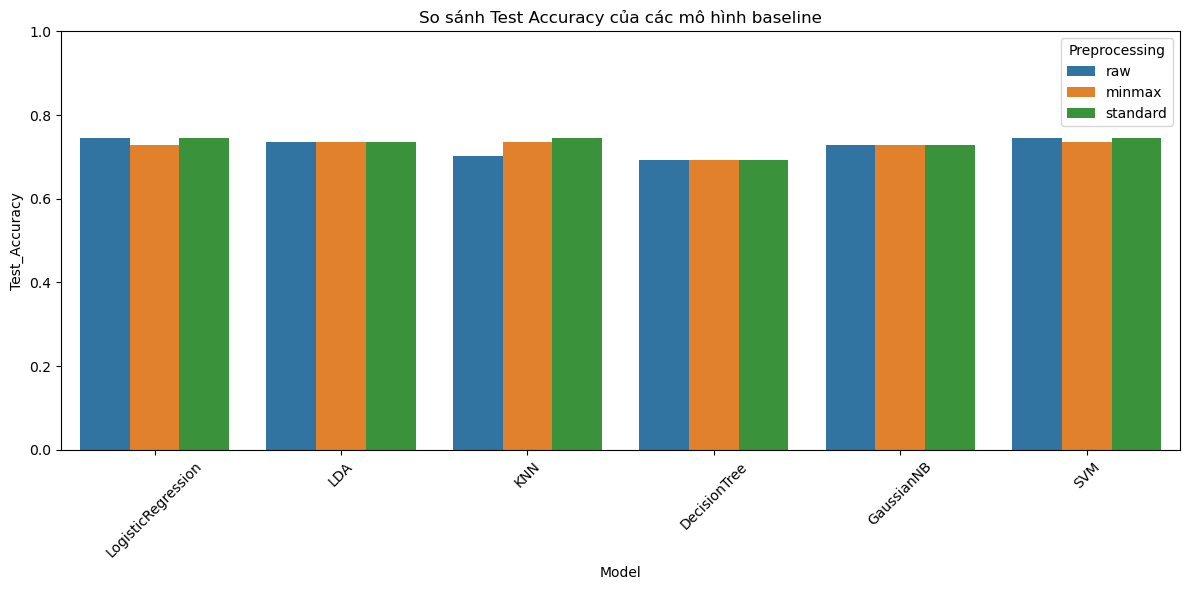

In [52]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Model", y="Test_Accuracy", hue="Preprocessing")
plt.xticks(rotation=45)
plt.title("So sánh Test Accuracy của các mô hình baseline")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_accuracy_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 23. Tối ưu siêu tham số cho KNN

Theo yêu cầu bài lab, KNN là một trong hai mô hình được tuning.  
Vì KNN nhạy với thang đo, ta dùng:
- median imputation
- StandardScaler
- GridSearchCV

In [53]:
knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 19],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best params for KNN:")
print(knn_grid.best_params_)
print("Best CV score:", knn_grid.best_score_)

Best params for KNN:
{'model__metric': 'euclidean', 'model__n_neighbors': 11, 'model__weights': 'uniform'}
Best CV score: 0.7673416407061266


## 24. Đánh giá KNN tối ưu trên tập test

In [54]:
best_knn = knn_grid.best_estimator_
knn_test_result = evaluate_on_test(best_knn, X_test, y_test)

knn_test_df = pd.DataFrame([knn_test_result], index=["Best KNN"])
knn_cv_df = pd.DataFrame(knn_grid.cv_results_).sort_values("rank_test_score").reset_index(drop=True)
knn_cv_df.to_csv(TABLES_DIR / "knn_gridsearch_results.csv", index=False)
knn_test_df.to_csv(TABLES_DIR / "knn_best_test_metrics.csv")
knn_test_df

,Accuracy,Precision,Recall,F1-score,AUC
Best KNN,0.748918,0.671642,0.555556,0.608108,0.814198


## 25. Tối ưu siêu tham số cho SVM

Mô hình SVM cũng nhạy với chuẩn hóa dữ liệu nên ta dùng:
- median imputation
- StandardScaler
- GridSearchCV

Các siêu tham số cần thử:
- `C`
- `kernel`
- `gamma`

In [55]:
svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

svm_param_grid = {
    "model__C": [0.1, 1, 10, 50],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", 0.01, 0.1, 1]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best params for SVM:")
print(svm_grid.best_params_)
print("Best CV score:", svm_grid.best_score_)

Best params for SVM:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best CV score: 0.7838698511595708


## 26. Đánh giá SVM tối ưu trên tập test

In [56]:
best_svm = svm_grid.best_estimator_
svm_test_result = evaluate_on_test(best_svm, X_test, y_test)

svm_test_df = pd.DataFrame([svm_test_result], index=["Best SVM"])
svm_cv_df = pd.DataFrame(svm_grid.cv_results_).sort_values("rank_test_score").reset_index(drop=True)
svm_cv_df.to_csv(TABLES_DIR / "svm_gridsearch_results.csv", index=False)
svm_test_df.to_csv(TABLES_DIR / "svm_best_test_metrics.csv")
svm_test_df

,Accuracy,Precision,Recall,F1-score,AUC
Best SVM,0.727273,0.655172,0.469136,0.546763,0.832757


## 27. So sánh mô hình tối ưu sau tuning

Bảng này so sánh trực tiếp:
- KNN sau tuning
- SVM sau tuning
- mô hình baseline tốt nhất trên tập test

In [57]:
baseline_best_idx = results_df.sort_values(
    by=["Test_Accuracy", "Test_AUC"],
    ascending=False
).index[0]

baseline_best_row = results_df.loc[baseline_best_idx]

final_compare_df = pd.DataFrame([
    {
        "Model": f"Baseline best: {baseline_best_row['Model']} ({baseline_best_row['Preprocessing']})",
        "Accuracy": baseline_best_row["Test_Accuracy"],
        "Precision": baseline_best_row["Test_Precision"],
        "Recall": baseline_best_row["Test_Recall"],
        "F1-score": baseline_best_row["Test_F1"],
        "AUC": baseline_best_row["Test_AUC"]
    },
    {
        "Model": "Tuned KNN (standard)",
        "Accuracy": knn_test_result["Accuracy"],
        "Precision": knn_test_result["Precision"],
        "Recall": knn_test_result["Recall"],
        "F1-score": knn_test_result["F1-score"],
        "AUC": knn_test_result["AUC"]
    },
    {
        "Model": "Tuned SVM (standard)",
        "Accuracy": svm_test_result["Accuracy"],
        "Precision": svm_test_result["Precision"],
        "Recall": svm_test_result["Recall"],
        "F1-score": svm_test_result["F1-score"],
        "AUC": svm_test_result["AUC"]
    }
])

final_compare_df = final_compare_df.sort_values(
    by=["Accuracy", "AUC"],
    ascending=False
).reset_index(drop=True)

final_compare_df.to_csv(TABLES_DIR / "final_model_comparison.csv", index=False)

final_compare_df

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Tuned KNN (standard),0.748918,0.671642,0.555556,0.608108,0.814198
1,Baseline best: LogisticRegression (standard),0.744589,0.671875,0.530864,0.593103,0.836296
2,Tuned SVM (standard),0.727273,0.655172,0.469136,0.546763,0.832757


## 28. Chọn mô hình cuối cùng tốt nhất

Ở đây ta chọn mô hình có `Accuracy` cao nhất; nếu bằng nhau thì ưu tiên mô hình có `AUC` cao hơn.

In [58]:
candidate_models = {
    f"Baseline best: {baseline_best_row['Model']} ({baseline_best_row['Preprocessing']})": (
        get_models(baseline_best_row["Preprocessing"])[baseline_best_row["Model"]]
    ),
    "Tuned KNN (standard)": best_knn,
    "Tuned SVM (standard)": best_svm
}

# Fit lại baseline best trên tập train nếu cần
baseline_model_name = f"Baseline best: {baseline_best_row['Model']} ({baseline_best_row['Preprocessing']})"
candidate_models[baseline_model_name].fit(X_train, y_train)

final_scores = []
for name, model in candidate_models.items():
    metrics = evaluate_on_test(model, X_test, y_test)
    final_scores.append({"Model": name, **metrics})

final_scores_df = pd.DataFrame(final_scores).sort_values(
    by=["Accuracy", "AUC"],
    ascending=False
).reset_index(drop=True)

final_scores_df.to_csv(TABLES_DIR / "final_candidate_scores.csv", index=False)

final_scores_df

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Tuned KNN (standard),0.748918,0.671642,0.555556,0.608108,0.814198
1,Baseline best: LogisticRegression (standard),0.744589,0.671875,0.530864,0.593103,0.836296
2,Tuned SVM (standard),0.727273,0.655172,0.469136,0.546763,0.832757


## 29. Ma trận nhầm lẫn và classification report của mô hình cuối cùng

Mô hình được chọn: Tuned KNN (standard)

Confusion Matrix:
[[128  22]
 [ 36  45]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7805    0.8533    0.8153       150
           1     0.6716    0.5556    0.6081        81

    accuracy                         0.7489       231
   macro avg     0.7261    0.7044    0.7117       231
weighted avg     0.7423    0.7489    0.7426       231



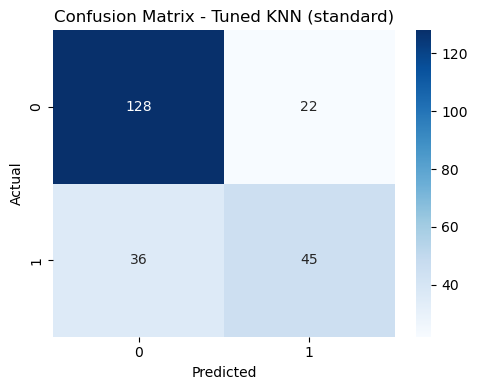

In [59]:
from sklearn.metrics import confusion_matrix, classification_report

best_model_name = final_scores_df.loc[0, "Model"]
best_model = candidate_models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
report_text = classification_report(y_test, y_pred_best, digits=4)

print("Mô hình được chọn:", best_model_name)
print()
print("Confusion Matrix:")
print(cm)
print()
print("Classification Report:")
print(report_text)

# Lưu kết quả ra file
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)
cm_df.to_csv(TABLES_DIR / "final_confusion_matrix.csv", index=True)

with open(TABLES_DIR / "final_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(f"Mô hình được chọn: {best_model_name}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(cm_df.to_string())
    f.write("\n\nClassification Report:\n")
    f.write(report_text)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## 30. Đường cong ROC của mô hình cuối cùng

ROC curve cho thấy khả năng phân tách giữa hai lớp của mô hình.  
AUC càng cao thì mô hình càng có khả năng phân biệt bệnh nhân mắc và không mắc bệnh.

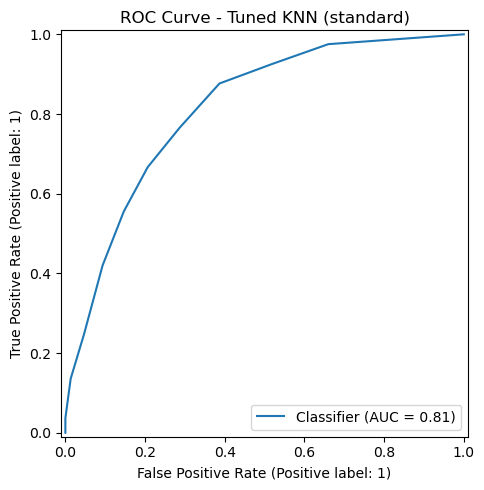

Final AUC: 0.8141975308641975


In [60]:
if hasattr(best_model, "predict_proba"):
    y_score_best = best_model.predict_proba(X_test)[:, 1]
else:
    y_score_best = best_model.decision_function(X_test)

RocCurveDisplay.from_predictions(y_test, y_score_best)
plt.title(f"ROC Curve - {best_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("Final AUC:", roc_auc_score(y_test, y_score_best))

## 31. Nhận xét kết quả

Từ các kết quả thu được, có thể rút ra một số nhận xét:

- Dữ liệu đã được xử lý 0 bất hợp lý thường cho kết quả ổn định hơn khi đưa vào mô hình.
- Các mô hình nhạy với thang đo như **KNN** và **SVM** thường được cải thiện khi dùng **Min-Max** hoặc **StandardScaler**.
- **Logistic Regression** và **LDA** thường cho kết quả khá ổn định trên dữ liệu Pima.
- **Decision Tree** đơn lẻ thường không nổi bật bằng các mô hình còn lại trong bài toán này.
- Bước **tuning** giúp KNN và SVM có cơ hội cải thiện thêm so với baseline.

# 32. Kết luận

Notebook đã thực hiện đầy đủ quy trình của một bài toán phân lớp dữ liệu bệnh tiểu đường Pima Indians:

1. xác định ý nghĩa bài toán  
2. phân tích dữ liệu  
3. xử lý giá trị 0 bất hợp lý  
4. chia dữ liệu train/test theo hold-out 7/3  
5. đánh giá nhiều mô hình baseline bằng cross validation  
6. so sánh dữ liệu thô / Min-Max / Standard  
7. tuning siêu tham số cho KNN và SVM  
8. chọn mô hình cuối cùng và kiểm nghiệm trên tập test  

Kết quả của notebook có thể dùng trực tiếp để:
- điền số liệu vào báo cáo Word
- chụp các bảng/biểu đồ đưa vào phụ lục
- giải thích phần thực nghiệm và kết luận của bài Lab 07

## 33. Xuất file kết quả

Sau khi chạy xong notebook, các bảng và hình sẽ được lưu trong thư mục `results/tables/` và `results/figures/` để tiện chèn vào báo cáo Word hoặc slide.

In [61]:

print("Các file đã lưu trong thư mục tables:")
for p in sorted(TABLES_DIR.glob("*")):
    print("-", p.name)

print("Các file đã lưu trong thư mục figures:")
for p in sorted(FIGURES_DIR.glob("*")):
    print("-", p.name)


Các file đã lưu trong thư mục tables:
- baseline_results_all_models.csv
- best_by_preprocessing.csv
- final_candidate_scores.csv
- final_classification_report.txt
- final_confusion_matrix.csv
- final_model_comparison.csv
- knn_best_test_metrics.csv
- knn_gridsearch_results.csv
- svm_best_test_metrics.csv
- svm_gridsearch_results.csv
Các file đã lưu trong thư mục figures:
- baseline_accuracy_comparison.png
- class_distribution.png
- correlation_heatmap.png
- feature_boxplots.png
- feature_histograms.png
- final_confusion_matrix.png
- final_roc_curve.png
